In [1]:
!pip install pandas numpy matplotlib statsmodels scikit-learn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [3]:
# Create monthly dates
dates = pd.date_range(start="2010-01-01", periods=180, freq="M")

# Create components of the time series
trend = np.linspace(50, 140, 180)  # slow upward trend
seasonality = 15 * np.sin(2 * np.pi * np.arange(180) / 12)  # yearly seasonal cycle
noise = np.random.normal(0, 4, 180)  # random noise

# Combine components
values = trend + seasonality + noise

# Add an anomaly / shock
values[120:125] += 25

# Put into DataFrame
df = pd.DataFrame({
    "date": dates,
    "value": values
})

# Save CSV file
df.to_csv("sample_data.csv", index=False)

# Show first rows
df.head()

/tmp/ipykernel_371/1633763753.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="2010-01-01", periods=180, freq="M")


,date,value
0,2010-01-31,51.986857
1,2010-02-28,57.449736
2,2010-03-31,66.586722
3,2010-04-30,72.600499
4,2010-05-31,64.064941


In [4]:
df.tail()

,date,value
175,2024-08-31,133.797560
176,2024-09-30,125.553247
177,2024-10-31,129.808550
178,2024-11-30,125.448198
179,2024-12-31,143.380677


In [5]:
df.describe()

,date,value
count,180,180.000000
mean,2017-07-15 18:16:00,95.605879
min,2010-01-31 00:00:00,39.154068
25%,2013-10-23 06:00:00,72.315133
50%,2017-07-15 12:00:00,95.400659
75%,2021-04-07 12:00:00,119.660908
max,2024-12-31 00:00:00,154.942340
std,NaN,29.246061


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    180 non-null    datetime64[ns]
 1   value   180 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.9 KB


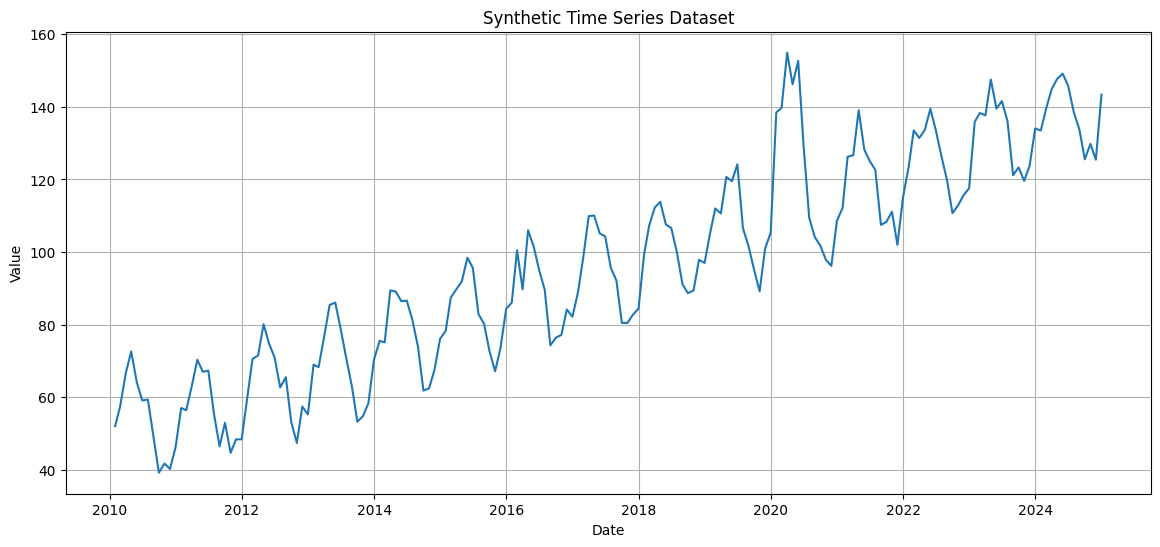

In [7]:
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["value"])
plt.title("Synthetic Time Series Dataset")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()

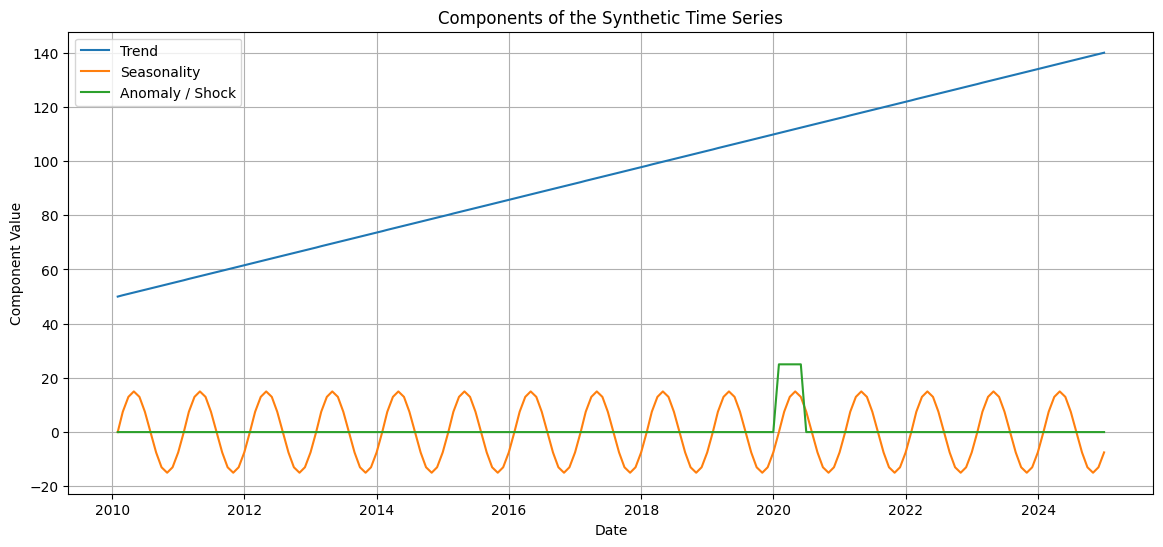

In [8]:
# Recreate components for plotting
trend = np.linspace(50, 140, 180)
seasonality = 15 * np.sin(2 * np.pi * np.arange(180) / 12)
noise = np.random.normal(0, 4, 180)
base_values = trend + seasonality + noise

# Add shock separately for visualization
shock = np.zeros(180)
shock[120:125] = 25

plt.figure(figsize=(14, 6))
plt.plot(dates, trend, label="Trend")
plt.plot(dates, seasonality, label="Seasonality")
plt.plot(dates, shock, label="Anomaly / Shock")
plt.title("Components of the Synthetic Time Series")
plt.xlabel("Date")
plt.ylabel("Component Value")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

ts = df[["date", "value"]].dropna().copy()
ts = ts.set_index("date")

ts.head()

,value
date,
2010-01-31,51.986857
2010-02-28,57.449736
2010-03-31,66.586722
2010-04-30,72.600499
2010-05-31,64.064941


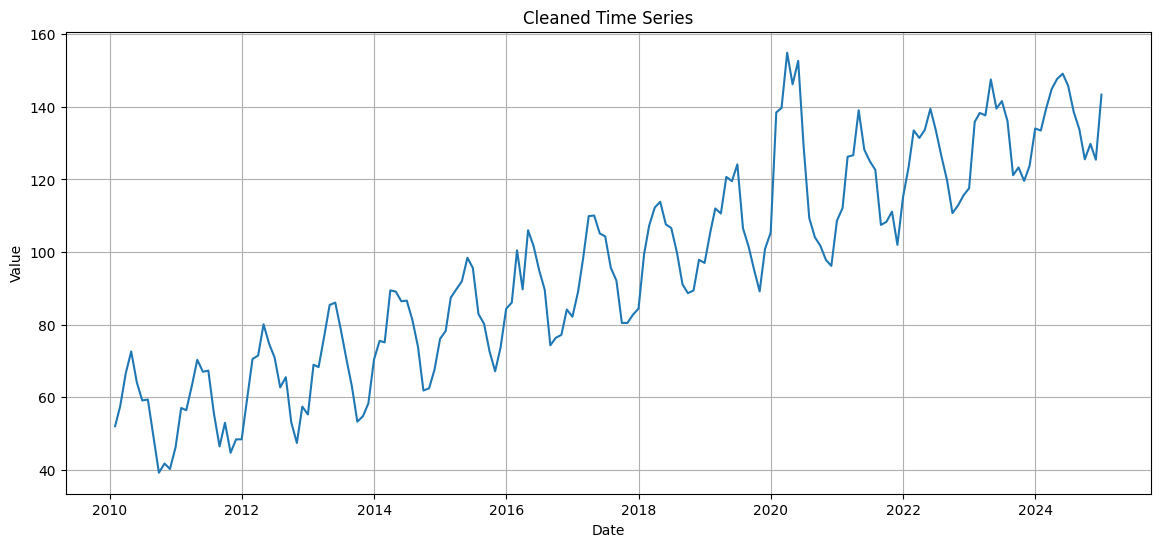

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(ts.index, ts["value"])
plt.title("Cleaned Time Series")
plt.xlabel("Date")
plt.ylabel("Value")
plt.grid(True)
plt.show()

In [11]:
test_size = max(12, int(len(ts) * 0.2))

train = ts.iloc[:-test_size]
test = ts.iloc[-test_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 144
Test size: 36


In [12]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [13]:
order = (2, 1, 2)

model = ARIMA(train["value"], order=order)
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  144
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -466.613
Date:                Thu, 12 Mar 2026   AIC                            943.227
Time:                        21:21:11   BIC                            958.041
Sample:                    01-31-2010   HQIC                           949.247
                         - 12-31-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7285      0.003    554.601      0.000       1.722       1.735
ar.L2         -0.9989      0.004   -262.397      0.000      -1.006      -0.991
ma.L1         -1.7443      0.131    -13.285      0.0

In [14]:
forecast = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test["value"], forecast)
rmse = mean_squared_error(test["value"], forecast) ** 0.5

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

MAE: 13.81
RMSE: 16.084


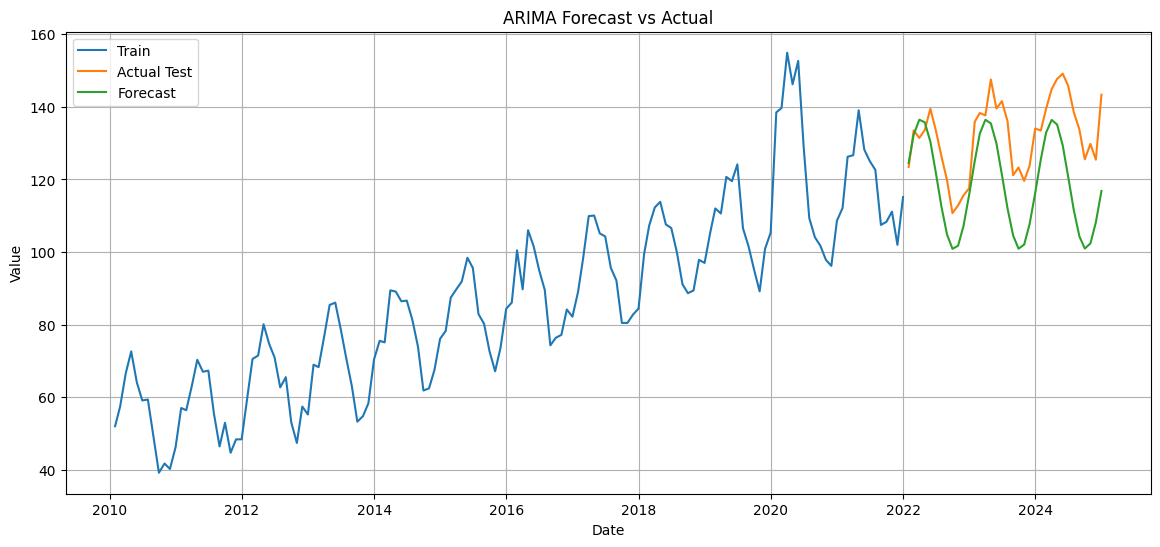

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["value"], label="Train")
plt.plot(test.index, test["value"], label="Actual Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
future_steps = 12

final_model = ARIMA(ts["value"], order=order).fit()
future_forecast = final_model.forecast(steps=future_steps)

last_date = ts.index[-1]
future_index = pd.date_range(start=last_date, periods=future_steps + 1, freq="M")[1:]

forecast_df = pd.DataFrame({
    "date": future_index,
    "forecast": future_forecast.values
})

forecast_df.head()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_371/383274694.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_index = pd.date_range(start=last_date, periods=future_steps + 1, freq="M")[1:]


,date,forecast
0,2025-01-31,151.331426
1,2025-02-28,158.714968
2,2025-03-31,163.547130
3,2025-04-30,164.529670
4,2025-05-31,161.399074


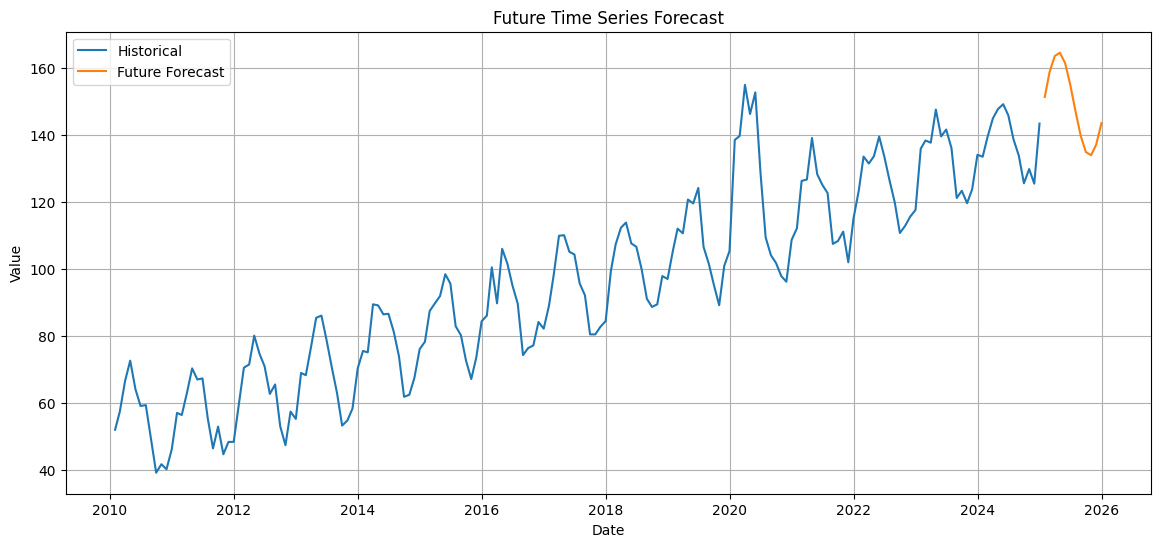

In [17]:
plt.figure(figsize=(14, 6))
plt.plot(ts.index, ts["value"], label="Historical")
plt.plot(forecast_df["date"], forecast_df["forecast"], label="Future Forecast")
plt.title("Future Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

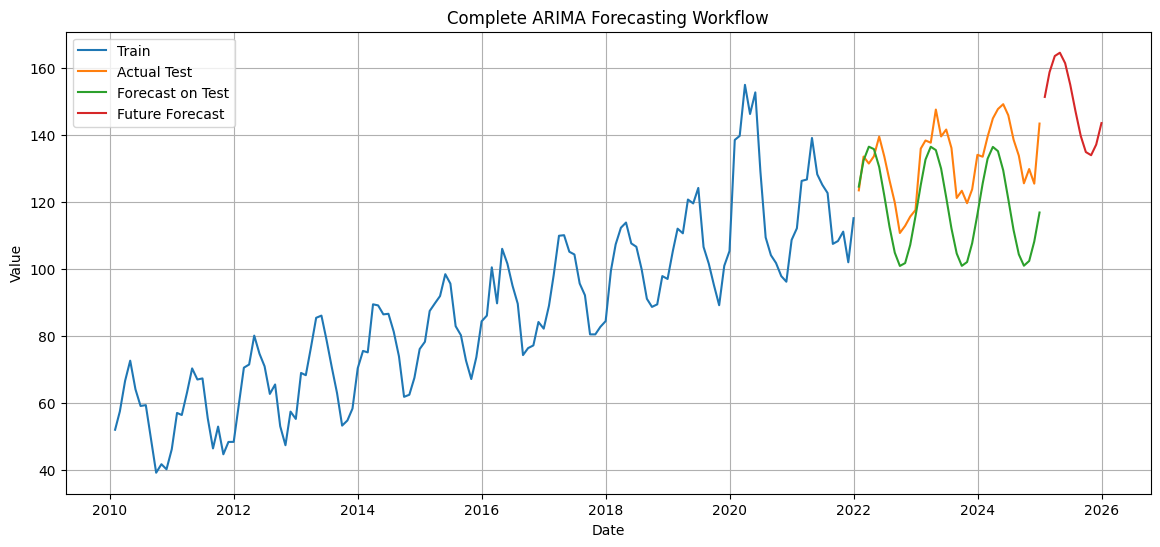

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["value"], label="Train")
plt.plot(test.index, test["value"], label="Actual Test")
plt.plot(test.index, forecast, label="Forecast on Test")
plt.plot(forecast_df["date"], forecast_df["forecast"], label="Future Forecast")
plt.title("Complete ARIMA Forecasting Workflow")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
recent_trend = ts["value"].iloc[-6:].mean() - ts["value"].iloc[-12:-6].mean()

if recent_trend > 0:
    trend_text = "an upward trend"
elif recent_trend < 0:
    trend_text = "a downward trend"
else:
    trend_text = "a relatively stable trend"

summary = f"""
This synthetic time series includes trend, seasonality, random noise, and a temporary anomaly.
The ARIMA model was trained to capture temporal structure and forecast future values.
On the test set, the model achieved an MAE of {mae:.2f} and RMSE of {rmse:.2f}.
Recent observations suggest {trend_text}.
"""

print(summary)


This synthetic time series includes trend, seasonality, random noise, and a temporary anomaly.
The ARIMA model was trained to capture temporal structure and forecast future values.
On the test set, the model achieved an MAE of 13.81 and RMSE of 16.08.
Recent observations suggest a downward trend.



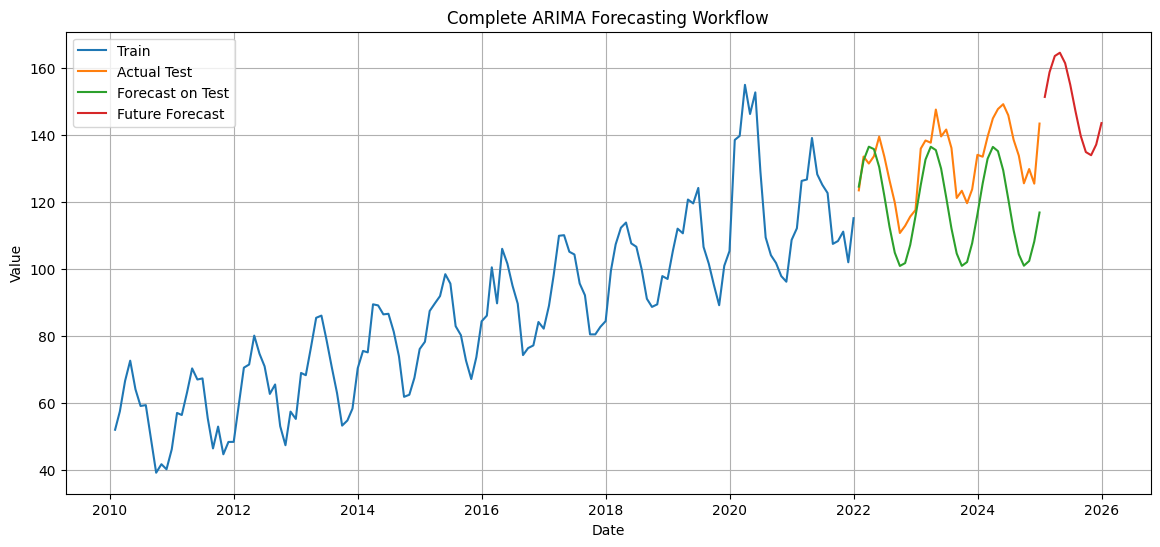

In [20]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["value"], label="Train")
plt.plot(test.index, test["value"], label="Actual Test")
plt.plot(test.index, forecast, label="Forecast on Test")
plt.plot(forecast_df["date"], forecast_df["forecast"], label="Future Forecast")
plt.title("Complete ARIMA Forecasting Workflow")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig("forecast_plot.png", dpi=300, bbox_inches="tight")
plt.show()

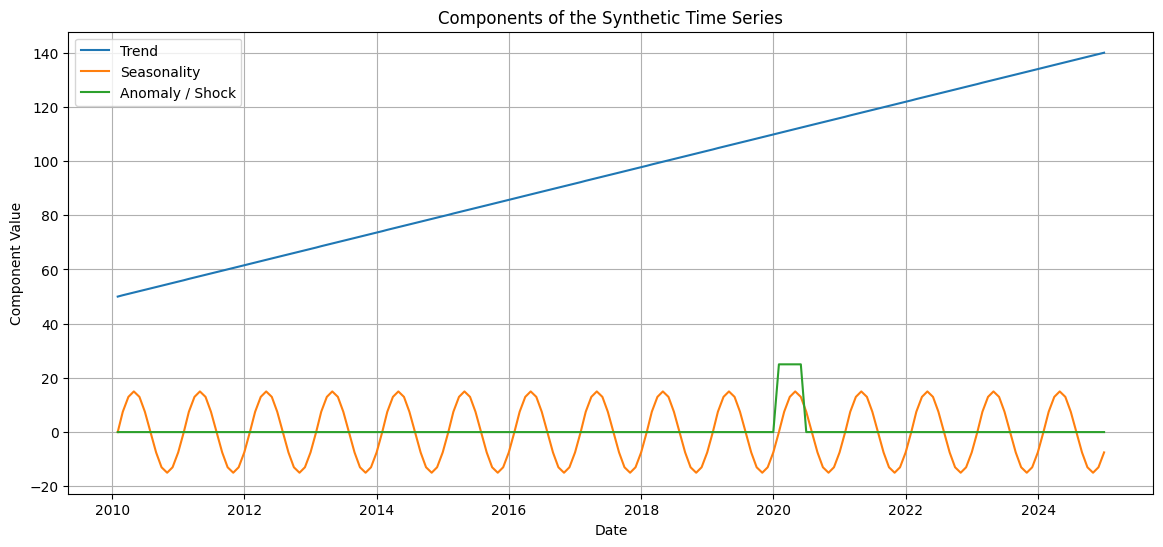

In [22]:
# Recreate components for plotting
trend = np.linspace(50, 140, 180)
seasonality = 15 * np.sin(2 * np.pi * np.arange(180) / 12)

shock = np.zeros(180)
shock[120:125] = 25

plt.figure(figsize=(14,6))
plt.plot(dates, trend, label="Trend")
plt.plot(dates, seasonality, label="Seasonality")
plt.plot(dates, shock, label="Anomaly / Shock")
plt.title("Components of the Synthetic Time Series")
plt.xlabel("Date")
plt.ylabel("Component Value")
plt.legend()
plt.grid(True)
plt.show()

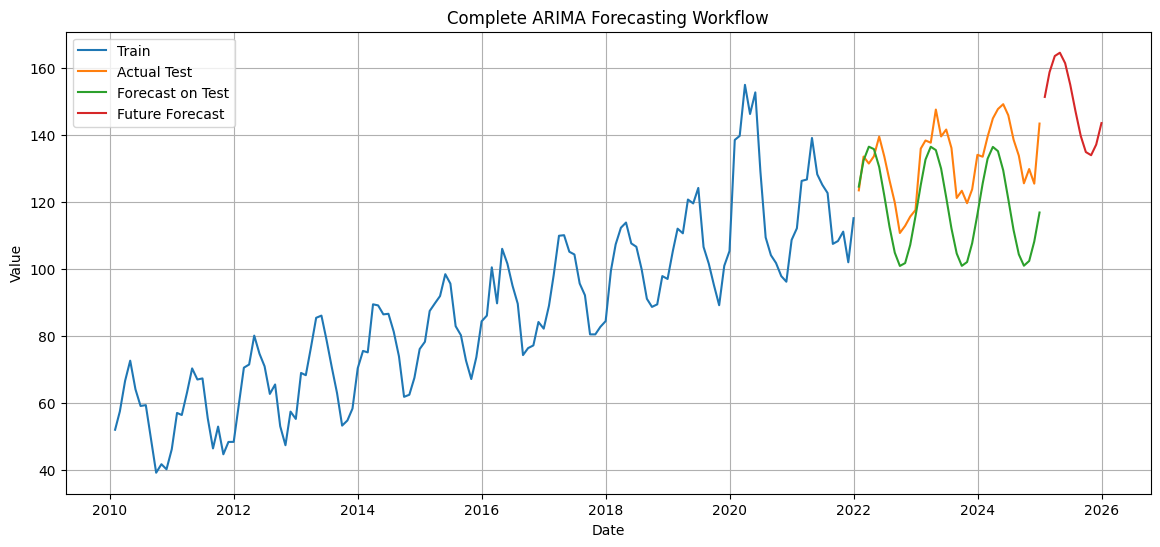

In [23]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train["value"], label="Train")
plt.plot(test.index, test["value"], label="Actual Test")
plt.plot(test.index, forecast, label="Forecast on Test")
plt.plot(forecast_df["date"], forecast_df["forecast"], label="Future Forecast")
plt.title("Complete ARIMA Forecasting Workflow")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

In [24]:
recent_trend = ts["value"].iloc[-6:].mean() - ts["value"].iloc[-12:-6].mean()

if recent_trend > 0:
    trend_text = "an upward trend"
elif recent_trend < 0:
    trend_text = "a downward trend"
else:
    trend_text = "a relatively stable trend"

summary = f"""
Time Series Forecasting Project Summary

This synthetic time series includes trend, seasonality, random noise, and a temporary anomaly.

The ARIMA model was trained to capture temporal structure and forecast future values.

Model performance:
MAE: {mae:.2f}
RMSE: {rmse:.2f}

Recent observations suggest {trend_text}.
"""

print(summary)


Time Series Forecasting Project Summary

This synthetic time series includes trend, seasonality, random noise, and a temporary anomaly.

The ARIMA model was trained to capture temporal structure and forecast future values.

Model performance:
MAE: 13.81
RMSE: 16.08

Recent observations suggest a downward trend.



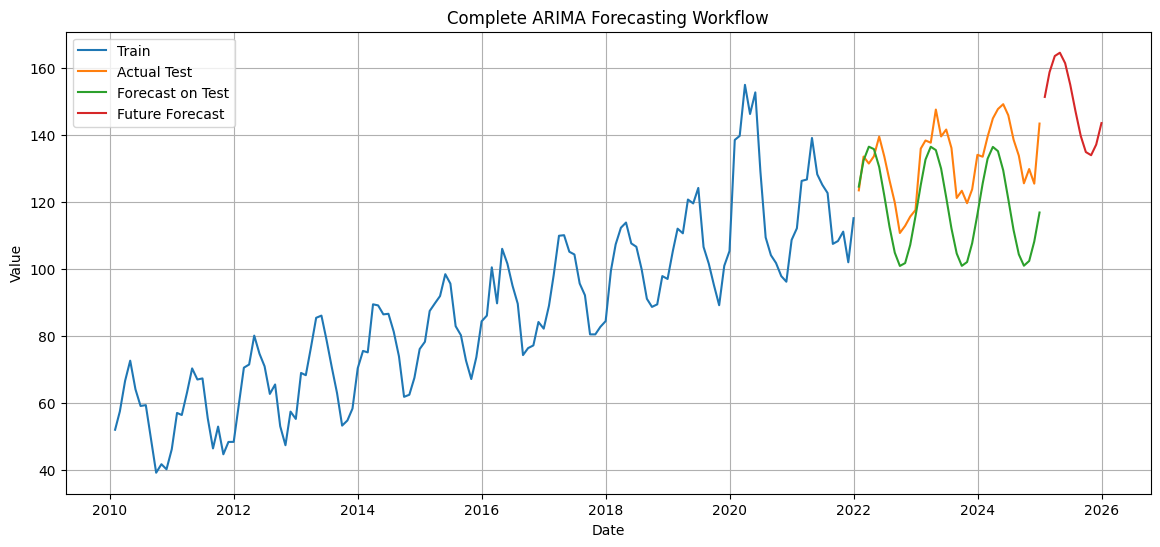

In [25]:
plt.figure(figsize=(14,6))
plt.plot(train.index, train["value"], label="Train")
plt.plot(test.index, test["value"], label="Actual Test")
plt.plot(test.index, forecast, label="Forecast on Test")
plt.plot(forecast_df["date"], forecast_df["forecast"], label="Future Forecast")
plt.title("Complete ARIMA Forecasting Workflow")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)

plt.savefig("complete_forecasting_workflow.png", dpi=300, bbox_inches="tight")
plt.show()

In [26]:
df.to_csv("synthetic_timeseries_data.csv", index=False)
forecast_df.to_csv("future_forecast.csv", index=False)

print("Files saved.")

Files saved.


In [27]:
from google.colab import files

files.download("synthetic_timeseries_data.csv")
files.download("future_forecast.csv")
files.download("complete_forecasting_workflow.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<Figure size 1200x500 with 0 Axes>

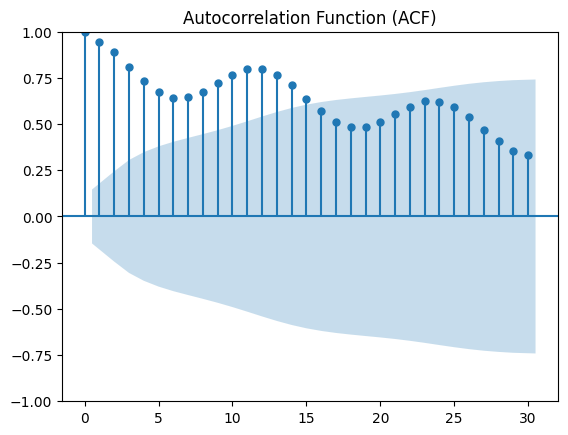

In [29]:
plt.figure(figsize=(12, 5))
plot_acf(ts["value"], lags=30)
plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1200x500 with 0 Axes>

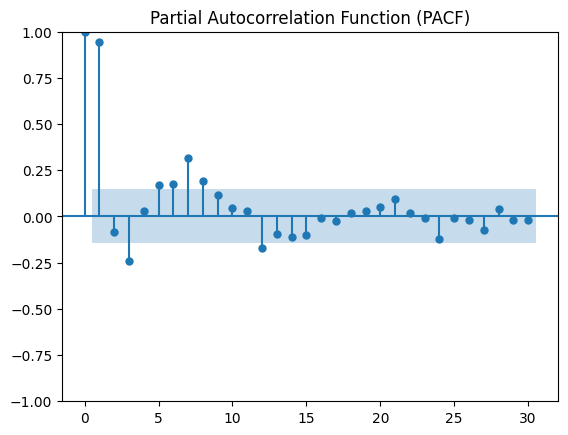

In [30]:
plt.figure(figsize=(12, 5))
plot_pacf(ts["value"], lags=30, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

<Figure size 1200x500 with 0 Axes>

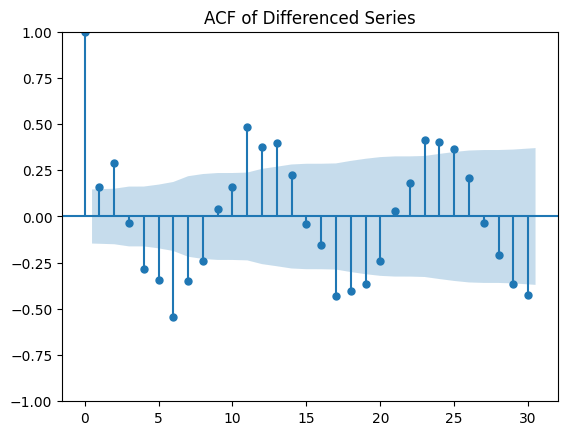

In [31]:
ts_diff = ts["value"].diff().dropna()

plt.figure(figsize=(12, 5))
plot_acf(ts_diff, lags=30)
plt.title("ACF of Differenced Series")
plt.show()

<Figure size 1200x500 with 0 Axes>

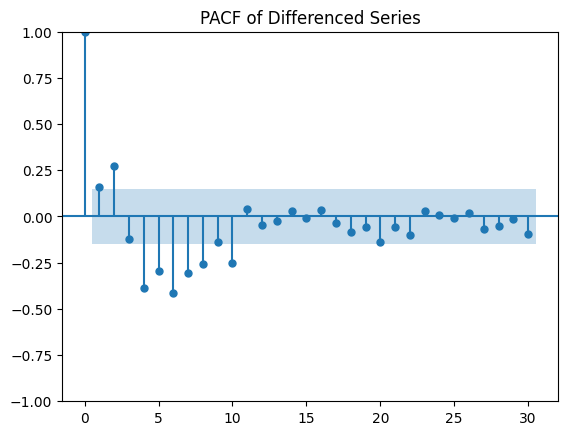

In [32]:
plt.figure(figsize=(12, 5))
plot_pacf(ts_diff, lags=30, method="ywm")
plt.title("PACF of Differenced Series")
plt.show()

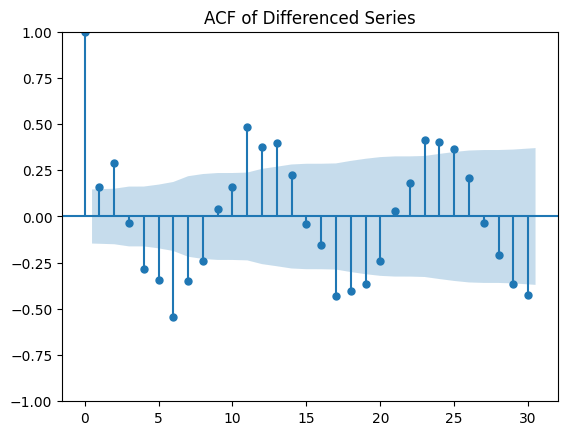

In [33]:
fig = plot_acf(ts_diff, lags=30)
plt.title("ACF of Differenced Series")
plt.savefig("acf_plot.png", dpi=300, bbox_inches="tight")
plt.show()

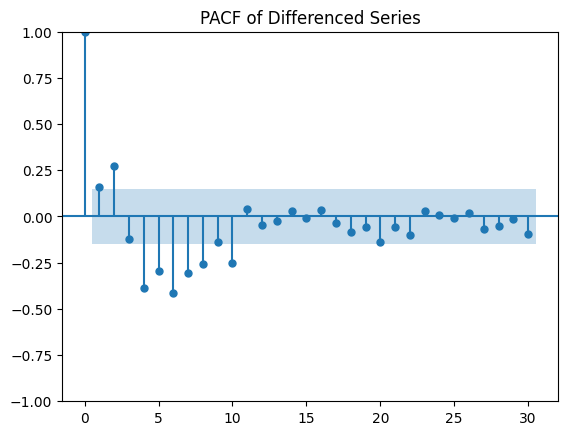

In [34]:
fig = plot_pacf(ts_diff, lags=30, method="ywm")
plt.title("PACF of Differenced Series")
plt.savefig("pacf_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
from google.colab import files

files.download("acf_plot.png")
files.download("pacf_plot.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

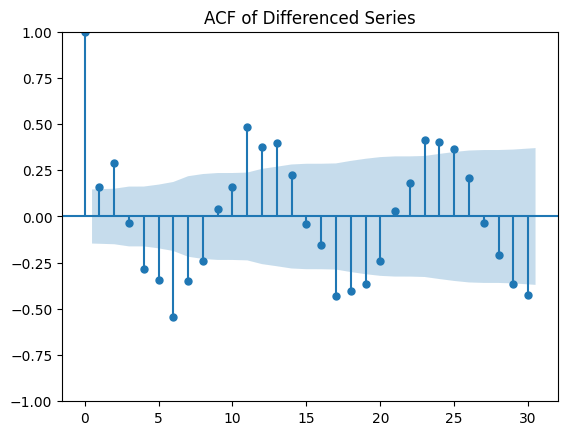

In [36]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff, lags=30)
plt.title("ACF of Differenced Series")
plt.show()

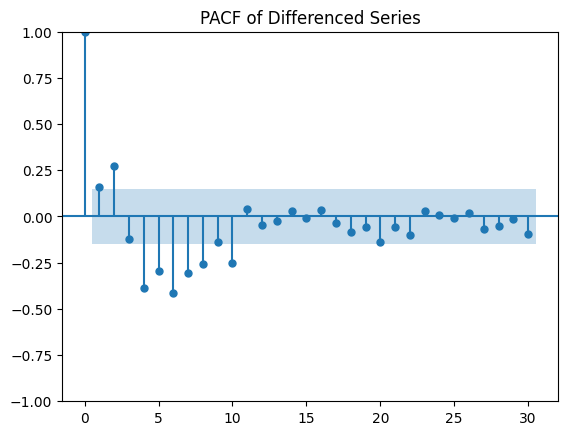

In [37]:
plot_pacf(ts_diff, lags=30, method="ywm")
plt.title("PACF of Differenced Series")
plt.show()

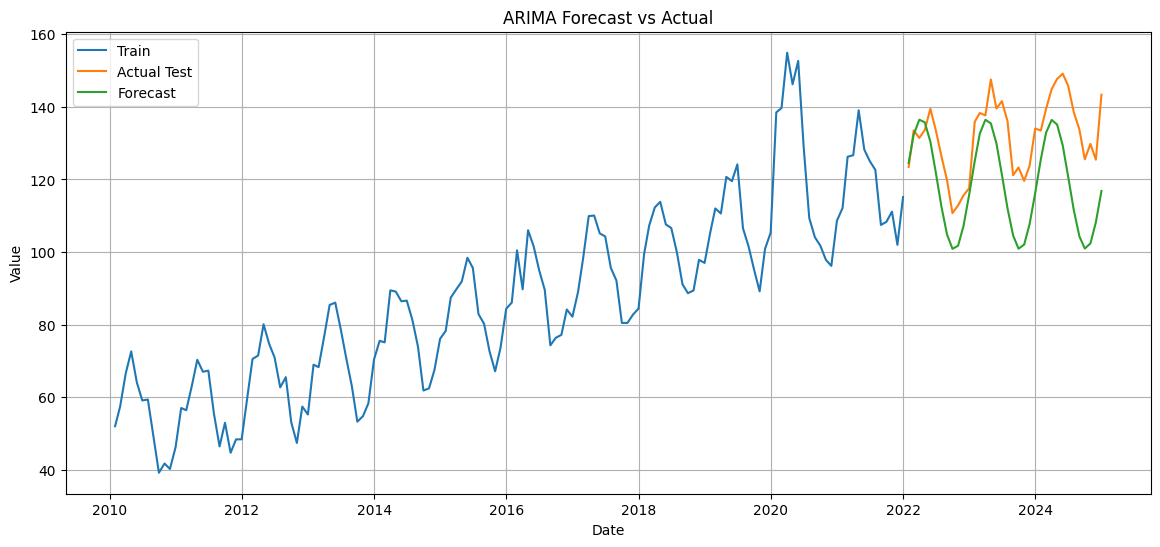

In [38]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train["value"], label="Train")
plt.plot(test.index, test["value"], label="Actual Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.savefig("forecast_vs_actual.png", dpi=300, bbox_inches="tight")
plt.show()

In [39]:
from google.colab import files
files.download("forecast_vs_actual.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
with open("project_summary.txt", "w") as f:
    f.write(summary)

print("Saved project_summary.txt")

Saved project_summary.txt


In [41]:
from google.colab import files
files.download("project_summary.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>